In [28]:
import pandas as pd
import numpy as np
from matplotlib import pyplot as plt

df = pd.read_csv('/content/train.csv')
unseen_df = pd.read_csv('/content/test.csv')
df.tail(10)

,age,job,marital,education,default,balance,housing,loan,contact,day,month,duration,campaign,pdays,previous,poutcome,y
45201,53,management,married,tertiary,no,583,no,no,cellular,17,nov,226,1,184,4,success,yes
45202,34,admin.,single,secondary,no,557,no,no,cellular,17,nov,224,1,-1,0,unknown,yes
45203,23,student,single,tertiary,no,113,no,no,cellular,17,nov,266,1,-1,0,unknown,yes
45204,73,retired,married,secondary,no,2850,no,no,cellular,17,nov,300,1,40,8,failure,yes
45205,25,technician,single,secondary,no,505,no,yes,cellular,17,nov,386,2,-1,0,unknown,yes
45206,51,technician,married,tertiary,no,825,no,no,cellular,17,nov,977,3,-1,0,unknown,yes
45207,71,retired,divorced,primary,no,1729,no,no,cellular,17,nov,456,2,-1,0,unknown,yes
45208,72,retired,married,secondary,no,5715,no,no,cellular,17,nov,1127,5,184,3,success,yes
45209,57,blue-collar,married,secondary,no,668,no,no,telephone,17,nov,508,4,-1,0,unknown,no
45210,37,entrepreneur,married,secondary,no,2971,no,no,cellular,17,nov,361,2,188,11,other,no


Inspecting df shape and data types



In [29]:
df.shape, unseen_df.shape

((45211, 17), (4521, 17))

In [30]:
print(df.dtypes)

age           int64
job          object
marital      object
education    object
default      object
balance       int64
housing      object
loan         object
contact      object
day           int64
month        object
duration      int64
campaign      int64
pdays         int64
previous      int64
poutcome     object
y            object
dtype: object


In [31]:
print(unseen_df.dtypes)

age           int64
job          object
marital      object
education    object
default      object
balance       int64
housing      object
loan         object
contact      object
day           int64
month        object
duration      int64
campaign      int64
pdays         int64
previous      int64
poutcome     object
y            object
dtype: object


In [32]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 45211 entries, 0 to 45210
Data columns (total 17 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   age        45211 non-null  int64 
 1   job        45211 non-null  object
 2   marital    45211 non-null  object
 3   education  45211 non-null  object
 4   default    45211 non-null  object
 5   balance    45211 non-null  int64 
 6   housing    45211 non-null  object
 7   loan       45211 non-null  object
 8   contact    45211 non-null  object
 9   day        45211 non-null  int64 
 10  month      45211 non-null  object
 11  duration   45211 non-null  int64 
 12  campaign   45211 non-null  int64 
 13  pdays      45211 non-null  int64 
 14  previous   45211 non-null  int64 
 15  poutcome   45211 non-null  object
 16  y          45211 non-null  object
dtypes: int64(7), object(10)
memory usage: 5.9+ MB


In [33]:
unseen_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4521 entries, 0 to 4520
Data columns (total 17 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   age        4521 non-null   int64 
 1   job        4521 non-null   object
 2   marital    4521 non-null   object
 3   education  4521 non-null   object
 4   default    4521 non-null   object
 5   balance    4521 non-null   int64 
 6   housing    4521 non-null   object
 7   loan       4521 non-null   object
 8   contact    4521 non-null   object
 9   day        4521 non-null   int64 
 10  month      4521 non-null   object
 11  duration   4521 non-null   int64 
 12  campaign   4521 non-null   int64 
 13  pdays      4521 non-null   int64 
 14  previous   4521 non-null   int64 
 15  poutcome   4521 non-null   object
 16  y          4521 non-null   object
dtypes: int64(7), object(10)
memory usage: 600.6+ KB


In [34]:
#Double-checking if all columns have non-null values
#Finding which columns have missing data

def missing(df):
  missing_dict = dict(df)
  total = df.shape[0]
  for attribute in df.columns:
    missing = df[attribute].isna().sum()
    frac = missing/total * 100 # as a percentage
    missing_dict[attribute] = frac
  return missing_dict

In [35]:
missing_dict_tr = missing(df)
missing_dict_tr

{'age': np.float64(0.0),
 'job': np.float64(0.0),
 'marital': np.float64(0.0),
 'education': np.float64(0.0),
 'default': np.float64(0.0),
 'balance': np.float64(0.0),
 'housing': np.float64(0.0),
 'loan': np.float64(0.0),
 'contact': np.float64(0.0),
 'day': np.float64(0.0),
 'month': np.float64(0.0),
 'duration': np.float64(0.0),
 'campaign': np.float64(0.0),
 'pdays': np.float64(0.0),
 'previous': np.float64(0.0),
 'poutcome': np.float64(0.0),
 'y': np.float64(0.0)}

In [36]:
missing_dict_ts = missing(unseen_df)
missing_dict_ts

{'age': np.float64(0.0),
 'job': np.float64(0.0),
 'marital': np.float64(0.0),
 'education': np.float64(0.0),
 'default': np.float64(0.0),
 'balance': np.float64(0.0),
 'housing': np.float64(0.0),
 'loan': np.float64(0.0),
 'contact': np.float64(0.0),
 'day': np.float64(0.0),
 'month': np.float64(0.0),
 'duration': np.float64(0.0),
 'campaign': np.float64(0.0),
 'pdays': np.float64(0.0),
 'previous': np.float64(0.0),
 'poutcome': np.float64(0.0),
 'y': np.float64(0.0)}

Confirmed there is no missing values in both train and test datasets.

In [37]:
#Checking any duplicates

dups = df.duplicated()
print('Number of duplicate rows = %d' % (dups.sum()))

Number of duplicate rows = 0


In [38]:
dups = unseen_df.duplicated()
print('Number of duplicate rows = %d' % (dups.sum()))

Number of duplicate rows = 0


No duplicated rows were found

In [39]:
# Identify categorical columns (object dtype)
object_cols = df.select_dtypes(include='object').columns
print("Object columns:", object_cols.tolist())

# Let's inspect the unique values in each object column
for col in object_cols:
    print(f"\nUnique values in '{col}':")
    print(df[col].unique())
    print(f"Number of unique values: {df[col].nunique()}")

Object columns: ['job', 'marital', 'education', 'default', 'housing', 'loan', 'contact', 'month', 'poutcome', 'y']

Unique values in 'job':
['management' 'technician' 'entrepreneur' 'blue-collar' 'unknown'
 'retired' 'admin.' 'services' 'self-employed' 'unemployed' 'housemaid'
 'student']
Number of unique values: 12

Unique values in 'marital':
['married' 'single' 'divorced']
Number of unique values: 3

Unique values in 'education':
['tertiary' 'secondary' 'unknown' 'primary']
Number of unique values: 4

Unique values in 'default':
['no' 'yes']
Number of unique values: 2

Unique values in 'housing':
['yes' 'no']
Number of unique values: 2

Unique values in 'loan':
['no' 'yes']
Number of unique values: 2

Unique values in 'contact':
['unknown' 'cellular' 'telephone']
Number of unique values: 3

Unique values in 'month':
['may' 'jun' 'jul' 'aug' 'oct' 'nov' 'dec' 'jan' 'feb' 'mar' 'apr' 'sep']
Number of unique values: 12

Unique values in 'poutcome':
['unknown' 'failure' 'other' 'success

Data Encoding - Converting string values to numeric values for training

### Re-encoding Categorical Variables

Given the discussion on appropriate encoding strategies, we will re-encode the categorical variables in a more suitable manner:

1.  **Reload Data**: To ensure we work with the original string values, we'll reload the `train.csv` and `test.csv` files.
2.  **Pre-processing `job` column**: Re-apply the 'unknown' to 'others' and 'admin.' to 'admin' replacements.
3.  **One-Hot Encoding**: For truly nominal columns like `job`, `marital`, `contact`, and `poutcome`.
4.  **Ordinal Encoding**: For columns with a clear order, such as `education` and `month`. We will define custom orders for these.
5.  **Label Encoding**: For binary columns like `default`, `housing`, `loan`, and `y`.

In [40]:
# Reload the original dataframes to revert previous Label Encoding
df = pd.read_csv('/content/train.csv')
unseen_df = pd.read_csv('/content/test.csv')

# Re-apply the 'job' column replacements
df['job'] = df['job'].replace({"unknown": "others", "admin.": "admin"})
unseen_df['job'] = unseen_df['job'].replace({"unknown": "others", "admin.": "admin"})

print("Data reloaded and 'job' column replacements re-applied.")

Data reloaded and 'job' column replacements re-applied.


In [41]:
from sklearn.preprocessing import OrdinalEncoder, LabelEncoder

# Identify categorical columns again
object_cols = df.select_dtypes(include='object').columns.tolist()

# Define nominal columns for One-Hot Encoding
nominal_cols = ['job', 'marital', 'contact', 'poutcome']

# Define ordinal columns and their specific order
ordinal_cols = {
    'education': ['unknown', 'primary', 'secondary', 'tertiary'], # Assuming 'unknown' is the lowest education level or a separate category without strong order within the known ones
    'month': ['jan', 'feb', 'mar', 'apr', 'may', 'jun', 'jul', 'aug', 'sep', 'oct', 'nov', 'dec']
}

# Define binary columns for Label Encoding
binary_cols = ['default', 'housing', 'loan', 'y']

# --- Apply One-Hot Encoding ---
# Create copies to avoid modifying original dfs during concatenation
df_ohe = df.copy()
unseen_df_ohe = unseen_df.copy()

df_ohe = pd.get_dummies(df_ohe, columns=nominal_cols, drop_first=True)
unseen_df_ohe = pd.get_dummies(unseen_df_ohe, columns=nominal_cols, drop_first=True)

# Ensure all columns created in training set are also in test set (fill with 0 if missing)
missing_cols_df = set(df_ohe.columns) - set(unseen_df_ohe.columns)
for c in missing_cols_df:
    unseen_df_ohe[c] = 0
missing_cols_unseen_df = set(unseen_df_ohe.columns) - set(df_ohe.columns)
for c in missing_cols_unseen_df:
    df_ohe[c] = 0

unseen_df_ohe = unseen_df_ohe[df_ohe.columns] # Align columns

# --- Apply Ordinal Encoding ---
for col, order in ordinal_cols.items():
    encoder = OrdinalEncoder(categories=[order], dtype=int)
    df_ohe[col] = encoder.fit_transform(df_ohe[[col]])
    unseen_df_ohe[col] = encoder.transform(unseen_df_ohe[[col]])

# --- Apply Label Encoding for Binary Features ---
for col in binary_cols:
    le = LabelEncoder()
    df_ohe[col] = le.fit_transform(df_ohe[col])
    unseen_df_ohe[col] = le.transform(unseen_df_ohe[col])

# Update df and unseen_df to the newly encoded dataframes
df = df_ohe
unseen_df = unseen_df_ohe

print("Encoding complete for all categorical columns.")
print("Updated df head:")
display(df.head())
print("Updated unseen_df head:")
display(unseen_df.head())

Encoding complete for all categorical columns.
Updated df head:


,age,education,default,balance,housing,loan,day,month,duration,campaign,...,job_student,job_technician,job_unemployed,marital_married,marital_single,contact_telephone,contact_unknown,poutcome_other,poutcome_success,poutcome_unknown
0,58,3,0,2143,1,0,5,4,261,1,...,False,False,False,True,False,False,True,False,False,True
1,44,2,0,29,1,0,5,4,151,1,...,False,True,False,False,True,False,True,False,False,True
2,33,2,0,2,1,1,5,4,76,1,...,False,False,False,True,False,False,True,False,False,True
3,47,0,0,1506,1,0,5,4,92,1,...,False,False,False,True,False,False,True,False,False,True
4,33,0,0,1,0,0,5,4,198,1,...,False,False,False,False,True,False,True,False,False,True


Updated unseen_df head:


,age,education,default,balance,housing,loan,day,month,duration,campaign,...,job_student,job_technician,job_unemployed,marital_married,marital_single,contact_telephone,contact_unknown,poutcome_other,poutcome_success,poutcome_unknown
0,30,1,0,1787,0,0,19,9,79,1,...,False,False,True,True,False,False,False,False,False,True
1,33,2,0,4789,1,1,11,4,220,1,...,False,False,False,True,False,False,False,False,False,False
2,35,3,0,1350,1,0,16,3,185,1,...,False,False,False,False,True,False,False,False,False,False
3,30,3,0,1476,1,1,3,5,199,4,...,False,False,False,True,False,False,True,False,False,True
4,59,2,0,0,1,0,5,4,226,1,...,False,False,False,True,False,False,True,False,False,True


array([[<Axes: title={'center': 'age'}>,
        <Axes: title={'center': 'education'}>,
        <Axes: title={'center': 'default'}>,
        <Axes: title={'center': 'balance'}>],
       [<Axes: title={'center': 'housing'}>,
        <Axes: title={'center': 'loan'}>,
        <Axes: title={'center': 'day'}>,
        <Axes: title={'center': 'month'}>],
       [<Axes: title={'center': 'duration'}>,
        <Axes: title={'center': 'campaign'}>,
        <Axes: title={'center': 'pdays'}>,
        <Axes: title={'center': 'previous'}>],
       [<Axes: title={'center': 'y'}>, <Axes: >, <Axes: >, <Axes: >]],
      dtype=object)

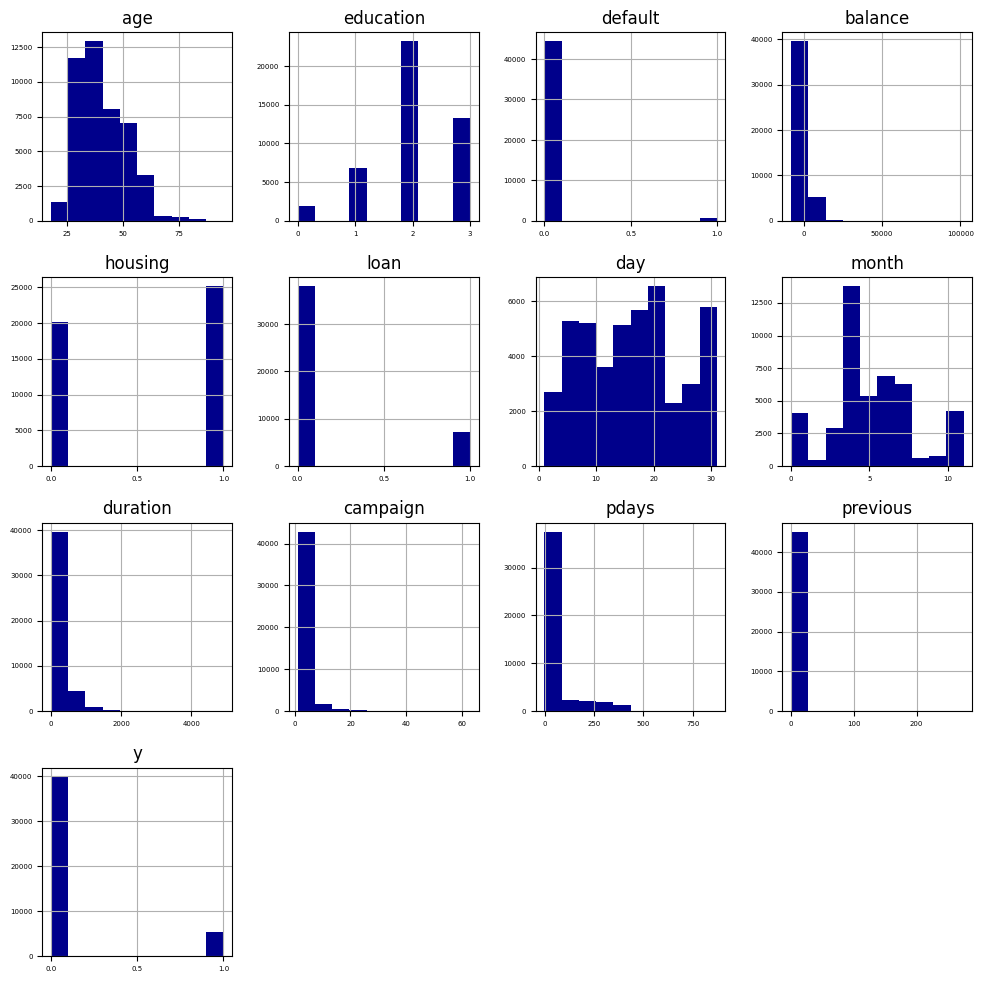

In [42]:
df.hist(xlabelsize=5, ylabelsize=5, color='darkblue', figsize=(12,12))

We see that the target variable has imbalance. So we'll use stratified sampling method.

In [43]:
## Separating the target variable from the dataset

X = df.drop('y', axis=1)
y = df['y']

X_unseen = unseen_df.drop('y', axis=1)
y_unseen = unseen_df['y']

In [44]:
X.shape, X_unseen.shape

((45211, 30), (4521, 30))

In [45]:
from sklearn.model_selection import StratifiedKFold, KFold, ShuffleSplit

In [46]:
# Train and validation set

skf = StratifiedKFold(n_splits=10)

for train_index, test_index in skf.split(X, y):
    x_train, x_test = X.iloc[train_index], X.iloc[test_index]
    y_train, y_test = y.iloc[train_index], y.iloc[test_index]

In [47]:
x_train.shape, x_test.shape, y_train.shape, y_test.shape

((40690, 30), (4521, 30), (40690,), (4521,))

In [48]:
# Checking if data imbalance is applied to the target variable
class_proportions = y_train.value_counts(normalize=True)
class_proportions

,proportion
y,
0,0.883018
1,0.116982


### Feature Scaling (Standardization)

Now, let's apply standardization to the numerical columns. This will transform them to have a mean of 0 and a standard deviation of 1. We will use `StandardScaler` from `sklearn.preprocessing`.

In [49]:
from sklearn.preprocessing import StandardScaler

# Identify numerical columns (excluding the already encoded ones and the target 'y')
# Filter out columns that are already boolean (from One-Hot Encoding) or ordinal encoded (int type)

# Get all numeric columns (int64 and float64)
numeric_cols = x_train.select_dtypes(include=['int64', 'float64']).columns.tolist()

# Exclude columns that have already been ordinal encoded or are binary (like 'default', 'housing', 'loan', 'y')
# We already processed 'education' and 'month' with OrdinalEncoder and 'default', 'housing', 'loan', 'y' with LabelEncoder (which converts them to int)
# The one-hot encoded columns are boolean, so they won't be in int64 unless explicitly converted

# Let's rebuild the list of columns to scale carefully:
# We need to scale 'age', 'balance', 'day', 'duration', 'campaign', 'pdays', 'previous'

# Make a list of columns that should be scaled (these are the original numeric features)
columns_to_scale = ['age', 'balance', 'day', 'duration', 'campaign', 'pdays', 'previous']

# Initialize the StandardScaler
scaler = StandardScaler()

# Apply StandardScaler to the selected numerical columns in both df(train and test) and unseen_df
x_train[columns_to_scale] = scaler.fit_transform(x_train[columns_to_scale])
x_test[columns_to_scale] = scaler.fit_transform(x_test[columns_to_scale])
unseen_df[columns_to_scale] = scaler.transform(unseen_df[columns_to_scale])

print("Numerical features standardized.")
print("Updated x_train head with scaled numerical features:")
display(x_train.head())
print("Updated x_test head with scaled numerical features:")
display(x_test.head())
print("Updated unseen_df head with scaled numerical features:")
display(unseen_df.head())

Numerical features standardized.
Updated x_train head with scaled numerical features:


/tmp/ipykernel_53095/533854302.py:23: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  x_train[columns_to_scale] = scaler.fit_transform(x_train[columns_to_scale])
/tmp/ipykernel_53095/533854302.py:24: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  x_test[columns_to_scale] = scaler.fit_transform(x_test[columns_to_scale])


,age,education,default,balance,housing,loan,day,month,duration,campaign,...,job_student,job_technician,job_unemployed,marital_married,marital_single,contact_telephone,contact_unknown,poutcome_other,poutcome_success,poutcome_unknown
0,1.714603,3,0,0.280838,1,0,-1.309659,4,-0.001638,-0.573754,...,False,False,False,True,False,False,True,False,False,True
1,0.316092,2,0,-0.433489,1,0,-1.309659,4,-0.423409,-0.573754,...,False,True,False,False,True,False,True,False,False,True
2,-0.782737,2,0,-0.442613,1,1,-1.309659,4,-0.710980,-0.573754,...,False,False,False,True,False,False,True,False,False,True
3,0.615773,0,0,0.065594,1,0,-1.309659,4,-0.649632,-0.573754,...,False,False,False,True,False,False,True,False,False,True
4,-0.782737,0,0,-0.442950,0,0,-1.309659,4,-0.243198,-0.573754,...,False,False,False,False,True,False,True,False,False,True


Updated x_test head with scaled numerical features:


,age,education,default,balance,housing,loan,day,month,duration,campaign,...,job_student,job_technician,job_unemployed,marital_married,marital_single,contact_telephone,contact_unknown,poutcome_other,poutcome_success,poutcome_unknown
38571,-0.589734,2,0,-0.546663,0,0,0.003152,4,0.304892,0.576208,...,False,True,False,True,False,False,False,False,False,True
38572,0.144036,1,0,-0.517703,1,1,0.003152,4,-0.142063,0.576208,...,False,False,False,False,False,False,False,False,False,False
38573,-0.656441,2,0,-0.437049,1,0,0.003152,4,-0.740982,3.641679,...,False,False,False,False,False,False,False,True,False,False
38574,-1.056679,2,0,-0.453559,1,0,0.003152,4,-0.562200,1.802396,...,False,False,False,False,True,False,False,False,False,True
38575,-0.122789,3,0,-0.819479,1,0,0.003152,4,4.604597,-0.036886,...,False,False,False,True,False,False,False,False,False,False


Updated unseen_df head with scaled numerical features:


,age,education,default,balance,housing,loan,day,month,duration,campaign,...,job_student,job_technician,job_unemployed,marital_married,marital_single,contact_telephone,contact_unknown,poutcome_other,poutcome_success,poutcome_unknown
0,-0.789853,1,0,-0.007797,0,0,0.486248,9,-0.669469,-0.649980,...,False,False,True,True,False,False,False,False,False,True
1,-0.589734,2,0,0.804696,1,1,-0.479944,4,-0.039263,-0.649980,...,False,False,False,True,False,False,False,False,False,False
2,-0.456321,3,0,-0.126072,1,0,0.123926,3,-0.195697,-0.649980,...,False,False,False,False,True,False,False,False,False,False
3,-0.789853,3,0,-0.091970,1,1,-1.446136,5,-0.133124,1.189302,...,False,False,False,True,False,False,True,False,False,True
4,1.144632,2,0,-0.491450,1,0,-1.204588,4,-0.012446,-0.649980,...,False,False,False,True,False,False,True,False,False,True


<Axes: >

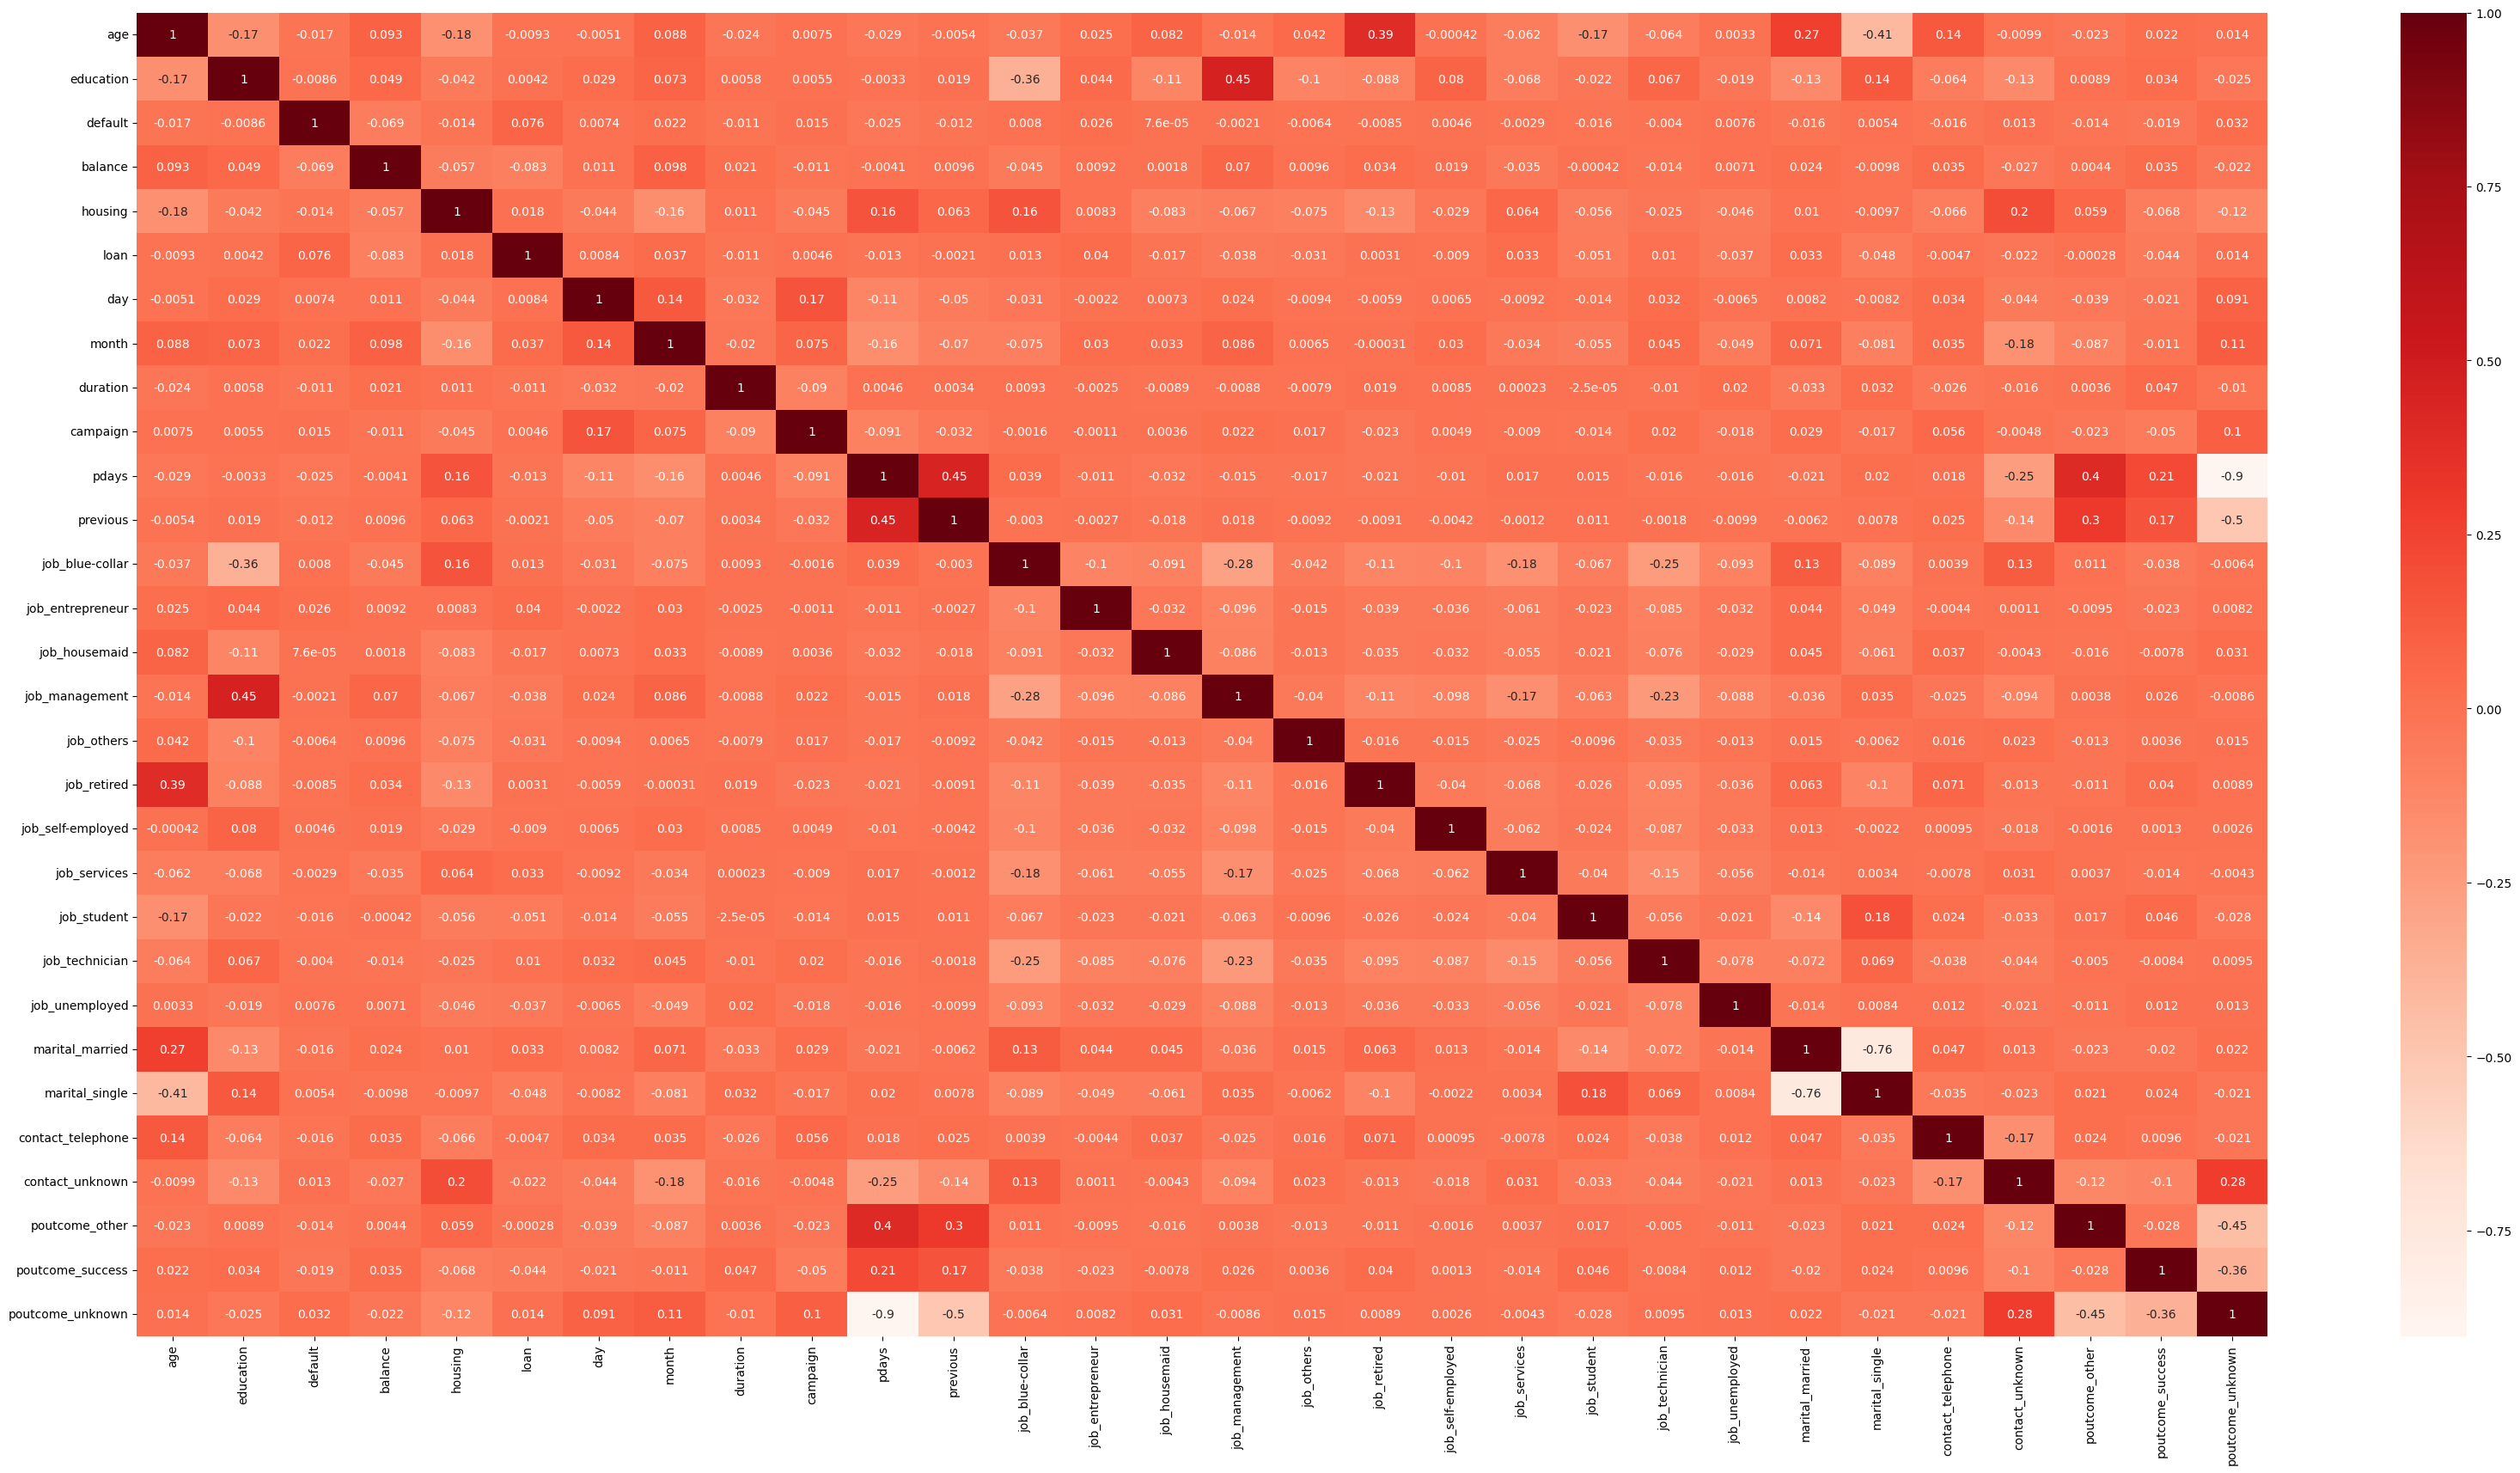

In [50]:
from matplotlib import pyplot as plt
import seaborn as sns

cor = x_train.corr()

fig, ax = plt.subplots(1,1,figsize=(40,20))

sns.heatmap(cor, annot=True, cmap=plt.cm.Reds, ax=ax)

We should drop "poutcome_unknown" to avoid multicollinearity. It has a strong negative (-0.9) linear relationship to "pdays".

In [51]:
x_train_clean = x_train.drop('poutcome_unknown', axis=1)
x_test_clean = x_test.drop('poutcome_unknown', axis=1)
unseen_df_clean = unseen_df.drop('poutcome_unknown', axis=1)

In [52]:
corr_y = x_train_clean.corrwith(y_train)
corr_y

,0
age,0.025566
education,0.055781
default,-0.022955
balance,0.062004
housing,-0.143992
loan,-0.070637
day,-0.029714
month,-0.007733
duration,0.408195
campaign,-0.075884


In [53]:
#Select features with higher correlation with the class
threshold = 0.025
highly_correlated_features = corr_y[abs(corr_y) > threshold]
highly_correlated_features

,0
age,0.025566
education,0.055781
balance,0.062004
housing,-0.143992
loan,-0.070637
day,-0.029714
duration,0.408195
campaign,-0.075884
pdays,0.101650
previous,0.086976


In [56]:
# Filter the datasets to keep only the highly correlated features
# Extract the column names from the index of the highly_correlated_features Series
selected_feature_names = highly_correlated_features.index.tolist()

x_train_selected = x_train_clean[selected_feature_names]
x_test_selected = x_test_clean[selected_feature_names]
X_unseen_selected = unseen_df_clean[selected_feature_names]

In [57]:
x_train = x_train_selected
x_test = x_test_selected
X_unseen = X_unseen_selected

In [58]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn import metrics
from sklearn.model_selection import cross_val_score, GridSearchCV
from sklearn.metrics import ConfusionMatrixDisplay, accuracy_score

# Create a dictionary of all the parameters
parameters = {'weights': ['uniform','distance'],
              'n_neighbors':[1,3,5,7,9,11,17,21,25]}
# make a classifier object
knn = KNeighborsClassifier()
# create a GridSearchCV object to do the training with cross validation
gscv = GridSearchCV(estimator=knn,
                    param_grid=parameters,
                    cv=skf,  # the cross validation folding pattern
                    scoring='accuracy')
# now train our model
best_knn = gscv.fit(x_train, y_train)

In [59]:
best_knn.best_params_, best_knn.best_score_

({'n_neighbors': 25, 'weights': 'uniform'}, np.float64(0.8891865323175228))

In [60]:
knn = KNeighborsClassifier(weights = best_knn.best_params_['weights'],
                            n_neighbors = best_knn.best_params_['n_neighbors'])
knn.fit(x_train, y_train)

KNeighborsClassifier(n_neighbors=25)

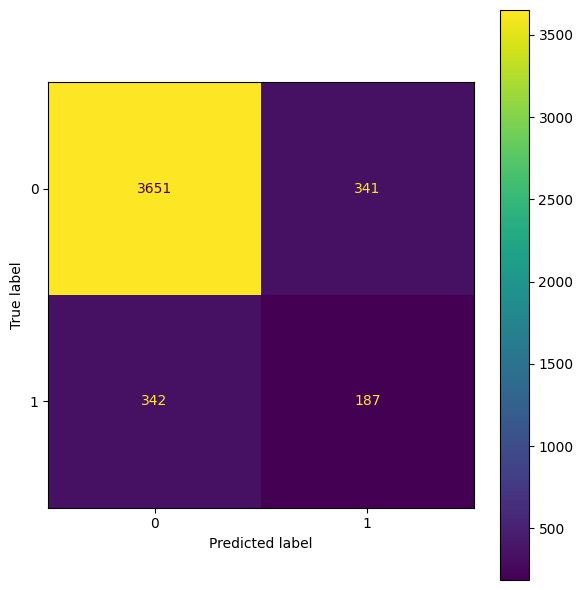

In [66]:
fig, ax = plt.subplots(1,1, figsize=(6, 6))
# Corrected: class_labels should reflect the actual unique classes in y_test (0 and 1)
class_labels = [0, 1]
ConfusionMatrixDisplay.from_estimator(knn,
                                      x_test, y_test,
                                      display_labels=class_labels,
                                      ax=ax)
plt.tight_layout()
plt.show()

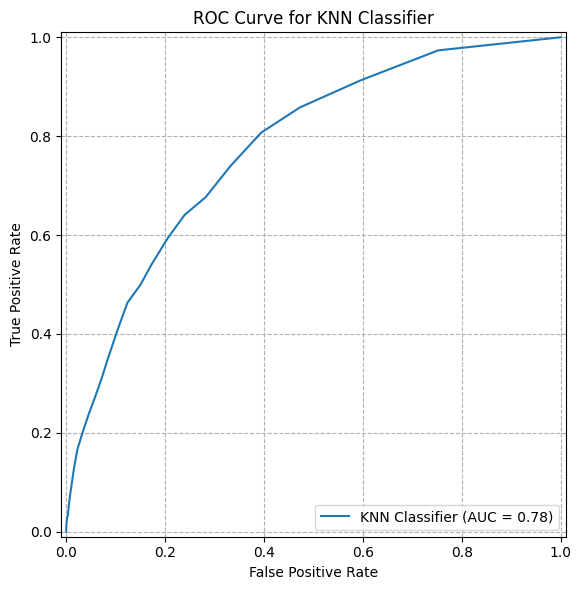

In [67]:
from sklearn.metrics import roc_curve, auc, RocCurveDisplay

# Get probability predictions for the positive class (class 1)
y_pred_proba = knn.predict_proba(x_test)[:, 1]

# Calculate ROC curve metrics
fpr, tpr, thresholds = roc_curve(y_test, y_pred_proba)
roc_auc = auc(fpr, tpr)

# Plot the ROC curve
fig, ax = plt.subplots(1, 1, figsize=(8, 6))
roc_display = RocCurveDisplay(fpr=fpr, tpr=tpr, roc_auc=roc_auc, estimator_name='KNN Classifier')
roc_display.plot(ax=ax)
plt.title('ROC Curve for KNN Classifier')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.grid(linestyle='--')
plt.tight_layout()
plt.show()

In [68]:
print(f"ROC AUC Score: {roc_auc:.4f}")

ROC AUC Score: 0.7762


## Feature Importance using SHAP and LIME

**SHAP (SHapley Additive exPlanations)** and **LIME (Local Interpretable Model-agnostic Explanations)** are powerful techniques for interpreting machine learning models. They help us understand *why* a model made a particular prediction for a specific instance, and also provide insights into the overall importance of features.

*   **SHAP** assigns an importance value to each feature for a particular prediction. These values, called Shapley values, represent the contribution of each feature to the difference between the actual prediction and the average prediction. SHAP has a strong theoretical foundation rooted in cooperative game theory.

*   **LIME** explains individual predictions by approximating the black-box model locally with an interpretable model (like a linear model) around the prediction point. It generates a new dataset consisting of perturbed samples and their predictions, then trains an interpretable model on this new dataset, weighting samples by their proximity to the instance being explained.

Both are 'model-agnostic', meaning they can be applied to any machine learning model.

In [69]:
# Install the shap library if you haven't already
!pip install shap

In [70]:
import shap

# Due to the computational intensity of KernelExplainer,
# we'll use a subsample of the background data for explanation.
# It is recommended to use a representative sample of your training data as background.
background = x_train.sample(n=100, random_state=42) # Using 100 samples for faster computation

# For KernelExplainer, the model's predict_proba method is preferred for classification
# as it provides probabilities which are more informative for SHAP values.
explainer = shap.KernelExplainer(knn.predict_proba, background)

# Calculate SHAP values for a subset of the test data (e.g., 50 samples)
# Explaining individual predictions can also be computationally intensive,
# so we'll use a small subset here.
x_test_sample = x_test.sample(n=50, random_state=42)
shap_values = explainer.shap_values(x_test_sample)

print("SHAP values calculated.")

  0%|          | 0/50 [00:00<?, ?it/s]

SHAP values calculated.


### Visualizing SHAP Feature Importance

We can use SHAP summary plots to get an overview of feature importance across the dataset.

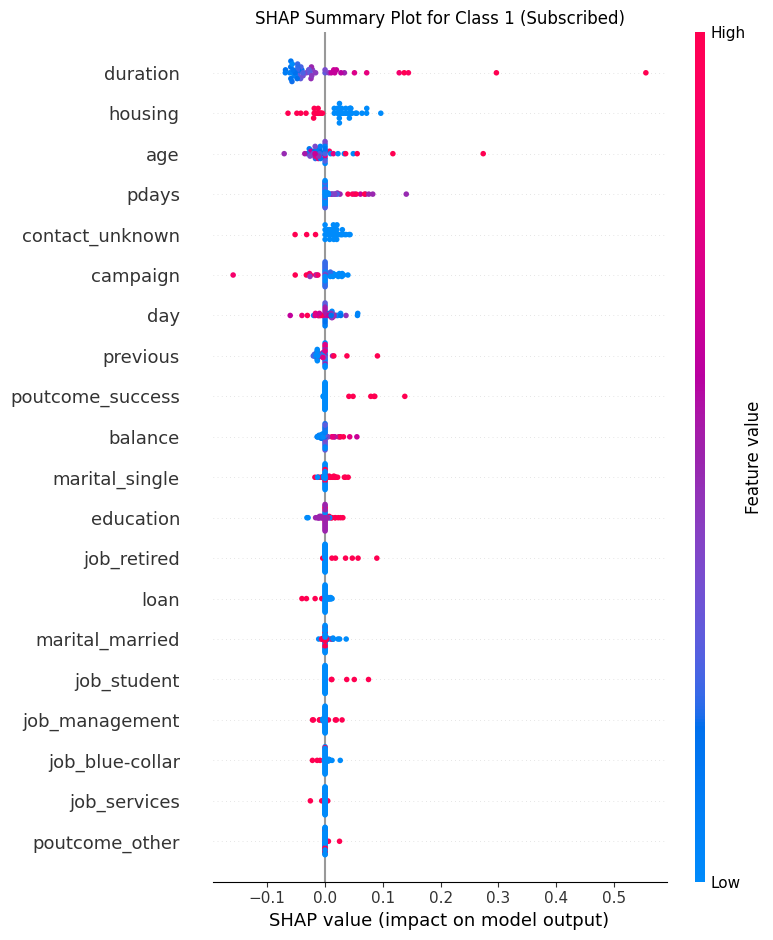

In [73]:
# Summary plot for class 1 (the positive class: 'yes' for term deposit subscription)
shap.summary_plot(shap_values[:, :, 1], x_test_sample, show=False)
plt.title('SHAP Summary Plot for Class 1 (Subscribed)')
plt.tight_layout()
plt.show()

The SHAP summary plot shows the distribution of SHAP values for each feature.

*   Each dot represents a data point from the `x_test_sample`.
*   The position of the dot on the x-axis indicates the SHAP value for that feature, showing how much that feature's value impacts the model's output (higher values push the prediction towards 'subscribed', lower towards 'not subscribed').
*   The color indicates the original value of the feature (e.g., red for high, blue for low).
*   Features are ordered by their overall importance (mean absolute SHAP value).

In [62]:
y_pred = knn.predict(x_test)
#true_labels = y_test.values
#predicted_labels = y_pred

In [63]:
accuracy = accuracy_score(y_test, y_pred)
accuracy

0.8489272284892723

In [65]:
y_unseen_pred = knn.predict(X_unseen)
accuracy_unseen = accuracy_score(y_unseen, y_unseen_pred)
print("Accuracy on Unseen Data:", accuracy_unseen)

Accuracy on Unseen Data: 0.8969254589692546
